# Margin Metric Tests

## Setup

### Imports

In [2]:
import logging
from math import isnan

import pytest

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *
from region_slice import empty_structure
from contour_plotting import plot_roi_slice


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [3]:
%matplotlib inline

### b) Function to identify relationships one each slice

In [3]:
def get_slice_relations(structure_a, structure_b):
    slices_a = set(structure_a.region_table['SliceIndex'])
    slices_b = set(structure_b.region_table['SliceIndex'])
    used_slices = slices_a | slices_b

    mask_a = structure_a.region_table.SliceIndex.isin(used_slices) & ~structure_a.region_table.Empty
    mask_b = structure_b.region_table.SliceIndex.isin(used_slices) & ~structure_b.region_table.Empty

    regions_a = structure_a.region_table.loc[mask_a, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions_b = structure_b.region_table.loc[mask_b, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions = regions_a.join(regions_b, how='outer', lsuffix='_a', rsuffix='_b').sort_index()

    cumulative = DE27IM()
    slice_rows = []

    for slice_index, row in regions.iterrows():
        region_a = row['RegionSlice_a']
        region_b = row['RegionSlice_b']

        relation = DE27IM(region_a, region_b)
        relation_type = relation.identify_relation()

        cumulative.merge(relation)
        cumulative_type = cumulative.identify_relation()

        slice_rows.append({
            'slice_index': float(slice_index),
            'a_present': not empty_structure(region_a),
            'b_present': not empty_structure(region_b),
            'slice_relation_type': relation_type.relation_type if relation_type else None,
            'slice_relation_label': relation_type.label if relation_type else None,
            'slice_de27im_bits': relation.relation,
            'slice_de27im_int': relation.int,
            'cumulative_relation_type': cumulative_type.relation_type if cumulative_type else None,
            'cumulative_relation_label': cumulative_type.label if cumulative_type else None,
            'cumulative_de27im_bits': cumulative.relation,
            'cumulative_de27im_int': cumulative.int,
        })

    slice_relation_df = pd.DataFrame(slice_rows).sort_values('slice_index').reset_index(drop=True)
    slice_relation_df.set_index('slice_index', inplace=True)
    return slice_relation_df, cumulative

## Orthogonal Z margin calculation process
<img src="../../Images/Box_in_Circle/Z Margin.png" alt="Z Margin" style="width: 8cm;">

1. Begin by identifying the relationships for each region pair
    - If the relationship is not one of the valid relationships 
        (CONTAINS, PARTITION, SURROUNDS, SHELTERS, CONFINES, EQUAL), set the 
        Z margin to NaN for that region pair.
    - If the relationship is EQUAL, set both z_neg and z_pos margins to 0 for 
        that region pair.
2. For region pairs with valid relationships, determine the starting and ending 
    slice indices for each of the two regions.
3. Calculate the initial values of z_neg and z_pos for each region pair:
   - z_neg = first_slice_b - first_slice_a
   - z_pos = last_slice_a - last_slice_b
3. If either z_neg or z_pos is negative, Set both the z_neg and z_pos margins to 
    NaN for that region pair, output a warning, and exclude that region pair from 
    the remaining steps.
4. Start with the lowest slice index of the region belonging to the inner 
    structure (B).
    1. find the previous (lower) slice index of the region belonging to the 
        outer structure (A). 
    2. If the difference between the two slice indexes is greater than or equal 
        to z_neg, keep the current value of z_neg and continue with the next 
        highest slice belonging to the inner structure (B).
    3. If the difference between the two slice indexes is less than z_neg check 
        whether the polygon(s) of the region belonging to the outer structure 
        (A) overlap with the polygon(s) of the region belonging to the inner 
        structure (B).  
    4. If they do, update z_neg to the difference between the two slice indexes. 
    5. If they do not, continue with the next slice in the negative direction 
        and keep the current value of z_neg.

- **Need specific criteria for determining whether the polygons of the two regions overlap.**

- **Identify relevant data structures**

5. Repeat steps 4a-4e for the z_pos margin, starting with the highest slice 
    index of the inner structure (B) and finding the next (higher) slice index 
    of the outer structure (A).
6. After iterating through all relevant slices of the inner structure (B), the 
    final values of z_neg and z_pos will represent the orthogonal Z margins for 
    that region pair.


<style>
table  {border-collapse:collapse;border-spacing:0;}
th td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:normal;font-weight:normal;color:black;overflow:hidden;padding:5px 3px;word-break:normal;}
.relate{background-color:#F2CEEF;color:black;font-size:normal;text-align:center;vertical-align:middle}
.poly-group{background-color:white;color:black;font-weight:bold;font-size:large;text-align:center;vertical-align:middle}
.poly-label_b{background-color:#161616;color:#00B050;font-size:large;font-weight:bold;text-align:center;vertical-align:middle}
.poly-label_a{background-color:#161616;color:#00B0F0;font-size:large;font-weight:bold;text-align:center;vertical-align:middle}
.poly-dim{background-color:#A02B93;color:white;font-size:medium;font-weight:700;text-align:center;vertical-align:middle}
.table-gap {background-color:#94DCF8;width:5px}
.group-border{border-right:3px solid #A34511}
.poly_a{color:#00B0F0;font-size:large;font-weight:bold}
.poly_b{color:#00B050;font-size:large;font-weight:bold}
</style>

Check on the possibility of adding tests for 
<b>Confines</b>, <b>Surrounds</b> and <b>Disjoint</b> relationships:

Does the <b>interior</b> of <span class="poly_a">A</span> include the 
<b>exterior</b> of  <span class="poly_b">B</span>? 

Does the <b>interior</b> of <span class="poly_b">B</span> include the 
<b>exterior</b> of <span class="poly_a">A</span>? 

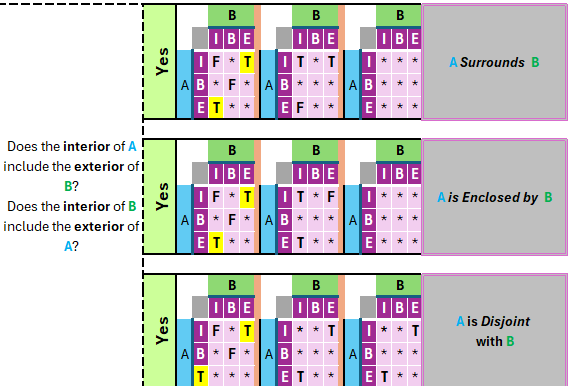

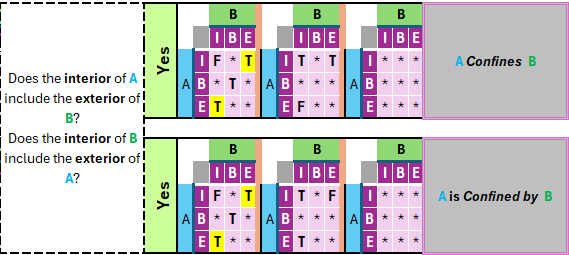

<table>
  <thead>
  <tr class="poly-group"><th>Region</th><th>External</th><th>Hull</th></tr>
  </thead>
  <tbody>
  <tr><td><table>
    <thead>  
      <tr>
        <th colspan="2" rowspan="2" style="border:none" />
        <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
      </tr>
      <tr>
        <th class="poly-dim">I</th>
        <th class="poly-dim">B</th>
        <th class="poly-dim group-border">E</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td class="poly-label_a" rowspan="3"><span class="poly_a">A</span></td>
        <td class="poly-dim">I</td>
        <td class="relate">T</td>
        <td class="relate">*</td>
        <td class="relate group-border">T</td>
      </tr>
      <tr>
        <td class="poly-dim">B</td>
        <td class="relate">*</td>
        <td class="relate"><B>F</B></td>
        <td class="relate group-border">*</td>
      </tr>
      <tr>
        <td class="poly-dim">E</td>
        <td class="relate"><B>F</B></td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
    </tbody>
  </table>
  </td><td><table>
    <thead>  
      <tr>
        <th colspan="2" rowspan="2" style="border:none" />
        <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
      </tr>
      <tr>
        <th class="poly-dim">I</th>
        <th class="poly-dim">B</th>
        <th class="poly-dim group-border">E</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td class="poly-label_a" rowspan="3"><span class="poly_a">A</span></td>
        <td class="poly-dim">I</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
      <tr>
        <td class="poly-dim">B</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
      <tr>
        <td class="poly-dim">E</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
    </tbody>
  </table>
  </td>
    </td><td><table>
    <thead>  
      <tr>
        <th colspan="2" rowspan="2" style="border:none" />
        <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
      </tr>
      <tr>
        <th class="poly-dim">I</th>
        <th class="poly-dim">B</th>
        <th class="poly-dim group-border">E</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td class="poly-label_a" rowspan="3"><span class="poly_a">A</span></td>
        <td class="poly-dim">I</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
      <tr>
        <td class="poly-dim">B</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
      <tr>
        <td class="poly-dim">E</td>
        <td class="relate">*</td>
        <td class="relate">*</td>
        <td class="relate group-border">*</td>
      </tr>
    </tbody>
  </table>
  </td></tr>

  </tbody>
  </table>

## Z margin relation

<style>
table  {border-collapse:collapse;border-spacing:0;}
th td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:normal;font-weight:normal;color:black;overflow:hidden;padding:5px 3px;word-break:normal;}
.relate{background-color:#F2CEEF;color:black;font-size:normal;text-align:center;vertical-align:middle}
.poly-group{background-color:white;color:black;font-weight:bold;font-size:large;text-align:center;vertical-align:middle}
.poly-label_b{background-color:#161616;color:#00B050;font-size:large;font-weight:bold;text-align:center;vertical-align:middle}
.poly-label_a{background-color:#161616;color:#00B0F0;font-size:large;font-weight:bold;text-align:center;vertical-align:middle}
.poly-dim{background-color:#A02B93;color:white;font-size:medium;font-weight:700;text-align:center;vertical-align:middle}
.table-gap {background-color:#94DCF8;width:5px}
.group-border{border-right:3px solid #A34511}
.poly_a{color:#00B0F0;font-size:large;font-weight:bold}
.poly_b{color:#00B050;font-size:large;font-weight:bold}
</style>

To trigger a Z margin the relationship between the <span class="poly_a">A</span> 
and <span class="poly_b">B</span> polygons must *change* to a relation where 
<span class="poly_b">B</span> is not fully contained within 
<span class="poly_a">A</span>.  

The change condition is important. For example, 
if the relationship between the two structures is:
<span class="poly_a">A</span> *CONTAINS* <span class="poly_b">B</span>, a 
change in relation to
<span class="p
oly_a">A</span> *is PARTITIONED by* <span class="poly_b">B</span> 
qualifies, but if the initial relationship is already *PARTITIONED* then a 
neighbouring slice with a relationship of *PARTITIONED* does not trigger a Z margin.

<img src="../../Images/DE-9IM.png" alt="DE_9IM Example" style="height:200px;"/>
<table>
  <thead>
    <tr>
      <th></th>
      <th>Contains</th>
      <th>Partitioned</th>
      <th>Surrounds<br>Shelters</th>
      <th>Confines</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>
        DE9IM region Matrix
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">T</td>
              <td class="relate">*</td>
              <td class="relate group-border">T</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate"><B>F</B></td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>F</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">T</td>
              <td class="relate">*</td>
              <td class="relate group-border">T</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate"><B>T</B></td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>F</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">F</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate">F</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">F</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate">T</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>
    </tr>
    <tr>
      <td><b>Z-Margin Criteria:</b><br>Check for:</td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate"><B>T</B></td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>T</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
        <code>
          mask =  0b100110000<br>
          value = 0b100000000
        </code>
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>T</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>*</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>      
      </td>
      <td>
        <table>
          <thead>
            <tr>
              <th colspan="2" rowspan="2" style="border:none" />
              <th class="poly-label_b" colspan="3"><span class="poly_b">B</span></th>
            </tr>
            <tr>
              <th class="poly-dim">I</th>
              <th class="poly-dim">B</th>
              <th class="poly-dim group-border">E</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td class="poly-label_b" rowspan="3"><span class="poly_a">A</span></td>
              <td class="poly-dim">I</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">B</td>
              <td class="relate">*</td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
            <tr>
              <td class="poly-dim">E</td>
              <td class="relate"><B>*</B></td>
              <td class="relate">*</td>
              <td class="relate group-border">*</td>
            </tr>
          </tbody>
        </table>
      </td>      
    </tr>
  </tbody>
</table>

<img src="../../Images/Box_in_Circle/Slice_Based_Orthogonal_Margin.png" alt="Slice Based Orthogonal Margin" style="width: 5cm;">

<img src="../../Images/Box_in_Circle/Slice_Based_Minimum_Margin.png" alt="Slice Based Minimum Margin" style="width: 5cm;">

For Z margin, 
- **Need to decide whether to base margins on boundary or original slices**

For each slice where only structure A exists:
1. overlap the polygon(s of A from that slice with the polygon(s) of B on its border slice(s).
2. check relationships for each region pair 
3. Identify the closest slice to the boundary slice where there is a change in the relationship from the one at the boundary slice, except for changes that results in A contains B
4. The difference between the slice index of the boundary slice and this slice is the Z margin in that direction 

## Minimum Margin calculation process


1. Begin by identifying the relationships for each region pair
    - If the relationship is not one of the valid relationships 
        (CONTAINS, SURROUNDS, SHELTERS, PARTITION, CONFINES, EQUAL), set the 
        Z margin to NaN for that region pair.
    - If the relationship is EQUAL, set both z_neg and z_pos margins to 0 for 
        that region pair.

2. ...


<img src="../../Images/Box_in_Circle/Ideal_Orthogonal_Margin.png" alt="Ideal Orthogonal Margin" style="width: 5cm;">

Minimum horizontal and vertical margin = $w_x = \sqrt{r^2 - (w/2)^2} - w/2 = \sqrt{16 - 4} - 2 = 1.46$

<img src="../../Images/Box_in_Circle/Ideal_Minimum_Margin.png" alt="Ideal Minimum Margin" style="width: 5cm;">


Minimum margin = $w_m = r - \sqrt{2  (w/2)^2} = 4 - \sqrt{8} = 1.17$

### Explain the process used to calculate margin metrics in the Z direction and then explain how that impacts on the minimum margin calculation

#### Entry point and metric used:
When you call calculate_metric with minimum_margins, StructureSet resolves the calculator through the registry and runs ContainmentMarginsCalculator. See structure_set.py and structure_set.py.

#### How Z-direction margins are currently computed:
1. During minimum_margins calculation, Z margins are computed in a dedicated step via _calculate_z_margins. See margins.py and margins.py.
2. For each region pair, it takes sorted slice indices from contour labels for structure A and B.
3. It computes:
   - z_neg = abs(first_slice_b - first_slice_a)
   - z_pos = abs(last_slice_a - last_slice_b)
   using the first and last slice index only. See margins.py and margins.py.
4. Those two values are rounded and merged into per-region orthogonal margins after x/y per-slice aggregation. See margins.py and margins.py.
5. Then overall orthogonal margins take the minimum across region pairs for each direction, including z_neg and z_pos. See margins.py and margins.py.

#### Important detail:
The Z logic uses slice index extents only. It does not include explicit half-slice extension or slice-thickness correction in this calculator, which matches the concern you noted in the notebook.

#### How this impacts minimum_margin:
It mostly does not, in the current implementation.

1. minimum_margin is computed in a separate path: _calculate_region_pair_minimum_margin. See margins.py.
2. That method only evaluates common slices (intersection of slice sets), then computes 2D boundary-to-boundary Shapely distance per shared slice, and takes the minimum. See margins.py and margins.py.
3. Final minimum_margin is min across region pairs from those per-region minima. See margins.py.
4. So z_neg/z_pos values are not used as inputs to minimum_margin. They are parallel outputs in the same MarginMetrics object, not part of the minimum-margin optimization itself. See data_structures.py.

#### Practical consequence:
- If Z orthogonal margins are off due to slice-boundary handling, your reported z_neg/z_pos can be wrong.
- minimum_margin can still be independently wrong for a different reason: it is currently a 2D minimum over overlapping slices only, so it may miss true 3D bottlenecks that involve through-plane effects. That is why Z-direction issues and minimum_margin issues can appear together but are not caused by the same calculation path.

## Orthogonal Margin Tests


### Embedded Boxes
![Embedded Boxes](<../../Images/FreeCAD Images/Embedded Boxes.png>)

In [5]:
def embedded_boxes_example():
    slice_spacing = 0.2
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = outer_cube + inner_cube + body
    return slice_data


slice_data = embedded_boxes_example()
embedded_box_structures = StructureSet(slice_data)
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')
assert relation_type .relation_type == 'CONTAINS'

# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = embedded_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")

# Expected: Margins should be 1 cm in all directions
expected_margins = {'x_neg': 1.0, 'x_pos': 1.0,
                    'y_neg': 1.0, 'y_pos': 1.0,
                    'z_neg': 1.0, 'z_pos': 1.0}
expected_minimum_margin = 1.0

for direction, value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    assert margin_result.orthogonal_margins[direction] == value, \
        f"Expected {value} in {direction} direction, got {margin_result.orthogonal_margins[direction]}."
assert margin_result.minimum_margin == expected_minimum_margin, \
    f"Expected minimum margin of {expected_minimum_margin}, got {margin_result.minimum_margin}."
print(f"\n✓ Orthogonal margins match expected values of {expected_margins}.")
print(f"\n✓ Minimum margin matches expected value of {expected_minimum_margin}.")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube
Orthogonal Margins: {'x_neg': 1.0, 'x_pos': 1.0, 'y_neg': 1.0, 'y_pos': 1.0, 'z_neg': 1.0, 'z_pos': 1.0}

✓ Orthogonal margins match expected values of {'x_neg': 1.0, 'x_pos': 1.0, 'y_neg': 1.0, 'y_pos': 1.0, 'z_neg': 1.0, 'z_pos': 1.0}.

✓ Minimum margin matches expected value of 1.0.


### Orthogonal Margin tests to do:

**Note:  When calculating margins in the Z direction, need to take into account**
**the half slices extension of the structures.**
In most cases it will cancel out.

- Simple case of embedded spheres
    - Equal margins in all directions ✓
- Embedded boxes not centred within each other
    - Different margins in the shifted directions ✓
- Box embedded and centered in sphere
    - Equal margins in all directions  **X**
- Multiple regions with the same margins
- Multiple regions with different margins.

- Sphere surrounded by hollow sphere
    - Margins in all directions are the same.

### Simple Embedded Sphere
![Embedded Spheres](<../../Images/FreeCAD Images/Embedded Spheres.png>)


In [ ]:
def simple_embedded_sphere_example():
    slice_spacing = 0.1
    # embedded spheres
    sphere6 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing, num_points=100)
    sphere3 = make_sphere(roi_num=2, radius=3, spacing=slice_spacing, num_points=100)
    # combine the contours
    slice_data = sphere6 + sphere3
    return slice_data

tolerance = 0.05
slice_data = simple_embedded_sphere_example()
embedded_sphere_structures = StructureSet(slice_data)
embedded_sphere_structures.tolerance = tolerance
structure_a = embedded_sphere_structures.structures[1]
structure_b = embedded_sphere_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Sphere {relation_type.label} Inner Sphere')
assert relation_type .relation_type == 'CONTAINS'

# Calculate margins between the two spheres (ROI 1 and ROI 2)
margin_result = embedded_sphere_structures.calculate_metric(1, 2, 'minimum_margins')

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")


# Expected: Margins should be 1 cm in all directions
expected_margins = {'x_neg': 3.0, 'x_pos': 3.0,
                    'y_neg': 3.0, 'y_pos': 3.0,
                    'z_neg': 3.0, 'z_pos': 3.0}
expected_minimum_margin = 3.0
for direction, value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    assert abs(margin_result.orthogonal_margins[direction] - value) <= tolerance, \
        f"Expected {value} in {direction} direction, got {margin_result.orthogonal_margins[direction]}."
assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
    f"Expected minimum margin of {expected_minimum_margin}, got {margin_result.minimum_margin}."
print(f"\n✓ Orthogonal margins match expected values of {expected_margins}.")
print(f"\n✓ Minimum margin matches expected value of {expected_minimum_margin}.")

INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Sphere Contains Inner Sphere
Orthogonal Margins: {'x_neg': 3.0, 'x_pos': 3.0, 'y_neg': 3.0, 'y_pos': 3.0, 'z_neg': 2.98, 'z_pos': 2.98}

✓ Orthogonal margins match expected values of {'x_neg': 3.0, 'x_pos': 3.0, 'y_neg': 3.0, 'y_pos': 3.0, 'z_neg': 3.0, 'z_pos': 3.0}.

✓ Minimum margin matches expected value of 3.0.


### Embedded Boxes Shifted
![Embedded Boxes Shifted (Image not yet created)](<../../Images/FreeCAD Images/Embedded Boxes Shiufted.png>)

In [ ]:
def shifted_embedded_boxes_example():
    slice_spacing = 0.2
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_cube = make_box(roi_num=1, width=8, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube = make_box(roi_num=2, width=2, offset_x=2, offset_y=-1, offset_z=1,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = outer_cube + inner_cube + body
    return slice_data


tolerance = 0.1
slice_data = shifted_embedded_boxes_example()
embedded_box_structures = StructureSet(slice_data)
embedded_box_structures.tolerance = tolerance
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')

# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = embedded_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")
print(f"Minimum Margin: {margin_result.minimum_margin}")


INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube
Orthogonal Margins: {'x_neg': 5.0, 'x_pos': 1.0, 'y_neg': 2.0, 'y_pos': 4.0, 'z_neg': 4.0, 'z_pos': 2.0}
Minimum Margin: 1.0


## Test whether distance is calculated in 3D by Shapely

Polygon has Z component: True
Distance between Outer Square and Inner Square is: 1.0
Distance ignores Z component


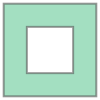

In [15]:
outer_square = shapely.Polygon([(-2, -2, 0), (2, -2, 0), (2, 2, 0), (-2, 2, 0)])
inner_square = shapely.Polygon([(-1, -1, 0), (1, -1, 0), (1, 1, 0), (-1, 1, 0)])
print(f'Polygon has Z component: {outer_square.has_z}')
print(f'Distance between Outer Square and Inner Square is: '
      f'{outer_square.boundary.distance(inner_square.boundary)}')
print('Distance ignores Z component')
outer_square - inner_square


# Done to Here

### Hourglass shape setup for margin testing

Use the reusable `make_hourglass_polygon` function to create an outer and inner complex shape.
The coordinates printed by the function can be used to validate expected margin-driving points.

Hourglass geometry report
  circle_radius=4.0000, neck_thickness=1.0000
  transition_steepness=1.5000, neck_half_width=1.0000
  solved_circle_half_spacing=4.6673
  left_circle_center=(-4.667324453600237, 0.0)
  right_circle_center=(4.667324453600237, 0.0)
  left_circle_extents={'x_min': -8.667324453600237, 'x_max': -0.6673244536002372, 'y_min': -4.0, 'y_max': 4.0}
  right_circle_extents={'x_min': 0.6673244536002372, 'x_max': 8.667324453600237, 'y_min': -4.0, 'y_max': 4.0}
  top_ellipse_center=(0.0, 2.0)
  bottom_ellipse_center=(0.0, -2.0)
  top_ellipse_extents={'x_min': -1.0, 'x_max': 1.0, 'y_min': 0.5, 'y_max': 3.5}
  bottom_ellipse_extents={'x_min': -1.0, 'x_max': 1.0, 'y_min': -3.5, 'y_max': -0.5}
  transition_points={'top_right': (0.8874592331810015, 1.308670667304652), 'top_left': (-0.8874592331810015, 1.308670667304652), 'bottom_right': (0.8874592331810015, -1.308670667304652), 'bottom_left': (-0.8874592331810015, -1.308670667304652)}
Outer area: 102.3508
Inner area: 78.1112
Shap

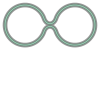

In [26]:
# Outer and inner hourglass polygons (contained case)
outer_poly = make_hourglass_polygon(
    circle_radius=4.0,
    neck_thickness=1.0,
    transition_steepness=1.5,
    neck_half_width=1.0,
    offset_x=0.0,
    offset_y=0.0,
    report_points=True,
    )

# Robust contained inner polygon: inward offset from the same hourglass
buffer_margin = 0.5
inner_poly = outer_poly.buffer(-buffer_margin)

if inner_poly.is_empty:
    raise ValueError('Inner hourglass became empty. Reduce buffer_margin.')
if inner_poly.geom_type != 'Polygon':
    raise ValueError('Inner hourglass is not a single polygon. Reduce buffer_margin.')

print(f'Outer area: {outer_poly.area:.4f}')
print(f'Inner area: {inner_poly.area:.4f}')
print(f'Shapely contains check: {outer_poly.contains(inner_poly)}')
outer_poly - inner_poly

In [27]:
# Convert polygons to contour slices for StructureSet margin tests
outer_slice_data = extrude_poly(
    polygon=outer_poly,
    length=6.0,
    spacing=0.2,
    offset_z=0.0,
    roi_num=1,
    )
inner_slice_data = extrude_poly(
    polygon=inner_poly,
    length=4.0,
    spacing=0.2,
    offset_z=0.0,
    roi_num=2,
    )

slice_data = outer_slice_data + inner_slice_data
hourglass_structures = StructureSet(slice_data)

relation = hourglass_structures.structures[1].relate(hourglass_structures.structures[2])
relation_type = relation.identify_relation()
print(f'Outer hourglass {relation_type.label} inner hourglass')

margin_result = hourglass_structures.calculate_metric(1, 2, 'minimum_margins')
print(f'Orthogonal Margins: {margin_result.orthogonal_margins}')
print(f'Minimum Margin: {margin_result.minimum_margin}')

INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


Outer hourglass Contains inner hourglass
Orthogonal Margins: {'x_neg': 0.5, 'x_pos': 0.5, 'y_neg': 0.5, 'y_pos': 0.5, 'z_neg': 0.95, 'z_pos': 0.95}
Minimum Margin: 0.5


### Box embedded and centered in sphere
![Box in Sphere (Image not yet created)](<../../Images/FreeCAD Images/Box_in_Sphere.png>)
- Equal orthogonal margins
- Different minimum Margin

In [8]:
def box_in_sphere_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # laterally shifted boxes
    outer_sphere = make_sphere(roi_num=1, radius=4, spacing=slice_spacing, num_points=300)
    inner_cube = make_box(roi_num=2, width=4, offset_x=0, offset_y=0, offset_z=0,
                          spacing=slice_spacing)
    # combine the contours
    slice_data = outer_sphere + inner_cube + body
    return slice_data

tolerance = 0.1
slice_data = box_in_sphere_example()
embedded_box_structures = StructureSet(slice_data)
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Sphere {relation_type.label} Inner Cube')

# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = embedded_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")
print(f"Minimum Margin: {margin_result.minimum_margin}")


INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Sphere Contains Inner Cube
Orthogonal Margins: {'x_neg': 1.43, 'x_pos': 1.43, 'y_neg': 1.43, 'y_pos': 1.43, 'z_neg': 2.0, 'z_pos': 2.0}
Minimum Margin: 0.61


In [9]:

assert relation_type.relation_type == 'CONTAINS', \
    f"Expected relationship CONTAINS, got relationship {relation_type.relation_type}"

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")

# Expected: Box is embedded in circle
# Orthogonal Margins should all be: 1.46
# Minimum margin should be 1.17 cm (diagonal)
expected_margins = {'x_neg': 1.46, 'x_pos': 1.46,
                    'y_neg': 1.46, 'y_pos': 1.46,
                    'z_neg': 1.46, 'z_pos': 1.46}
expected_minimum_margin = 1.17

for direction, value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    assert abs(margin_result.orthogonal_margins[direction] - value) <= tolerance, \
        f"Expected {value} in {direction} direction, got {margin_result.orthogonal_margins[direction]}."
assert abs(margin_result.minimum_margin - expected_minimum_margin) <= tolerance, \
    f"Expected minimum margin of {expected_minimum_margin}, got {margin_result.minimum_margin}."
print(f"\n✓ Orthogonal margins match expected values of {expected_margins}.")
print(f"\n✓ Minimum margin matches expected value of {expected_minimum_margin}.")

Orthogonal Margins: {'x_neg': 1.43, 'x_pos': 1.43, 'y_neg': 1.43, 'y_pos': 1.43, 'z_neg': 2.0, 'z_pos': 2.0}


AssertionError: Expected 1.46 in z_neg direction, got 2.0.

### Multiple regions with the same margins

In [13]:
def multi_embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                spacing=slice_spacing)
    # Centred boxes
    outer_cube1 = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    inner_cube1 = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # Laterally Shifted boxes
    outer_cube2 = make_box(roi_num=1, width=4, offset_x=4, offset_z=0,
                         spacing=slice_spacing)
    inner_cube2 = make_box(roi_num=2, width=2, offset_x=4, offset_z=0,
                         spacing=slice_spacing)
    # Vertically Shifted boxes
    outer_cube3 = make_box(roi_num=1, width=4, offset_x=0, offset_z=4,
                         spacing=slice_spacing)
    inner_cube3 = make_box(roi_num=2, width=2, offset_x=0, offset_z=4,
                         spacing=slice_spacing)

    # combine the contours
    slice_data = outer_cube1 + inner_cube1 + outer_cube2 + inner_cube2 + outer_cube3 + inner_cube3 + body
    return slice_data


slice_data = multi_embedded_boxes_example()
embedded_box_structures = StructureSet(slice_data)
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Cube {relation_type.label} Inner Cube')
assert relation_type .relation_type == 'CONTAINS'

# Calculate margins between the two boxes (ROI 1 and ROI 2)
margin_result = embedded_box_structures.calculate_metric(1, 2, 'minimum_margins')

# Display results
print(f"Orthogonal Margins: {margin_result.orthogonal_margins}")


INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Overlaps with
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Cube Contains Inner Cube
Orthogonal Margins: {'x_neg': 1.0, 'x_pos': 1.0, 'y_neg': 1.0, 'y_pos': 1.0, 'z_neg': 0.9, 'z_pos': 0.9}


In [14]:
margin_result.per_region_orthogonal_margins

{(0, 0): {'x_neg': 2.0,
  'x_pos': 2.0,
  'y_neg': 2.0,
  'y_pos': 2.0,
  'z_neg': 1.0,
  'z_pos': 0.9},
 (0, 1): {'x_neg': 2.0,
  'x_pos': 2.0,
  'y_neg': 2.0,
  'y_pos': 2.0,
  'z_neg': 1.0,
  'z_pos': 0.9},
 (1, 0): {'x_neg': 2.0,
  'x_pos': 2.0,
  'y_neg': 2.0,
  'y_pos': 2.0,
  'z_neg': 1.0,
  'z_pos': 1.0},
 (1, 1): {'x_neg': 2.0,
  'x_pos': 2.0,
  'y_neg': 2.0,
  'y_pos': 2.0,
  'z_neg': 1.0,
  'z_pos': 1.0},
 (4, 2): {'x_neg': 1.0,
  'x_pos': 1.0,
  'y_neg': 1.0,
  'y_pos': 1.0,
  'z_neg': 0.9,
  'z_pos': 0.98}}

In [ ]:

# Expected: Margins should be 1 cm in all directions
expected_margins = {'x_neg': 1.0, 'x_pos': 1.0,
                    'y_neg': 1.0, 'y_pos': 1.0,
                    'z_neg': 1.0, 'z_pos': 1.0}
expected_minimum_margin = 1.0

for direction, value in expected_margins.items():
    assert direction in margin_result.orthogonal_margins, \
        f"{direction} was not found in margin_result, got {margin_result.orthogonal_margins}."
    assert margin_result.orthogonal_margins[direction] == value, \
        f"Expected {value} in {direction} direction, got {margin_result.orthogonal_margins[direction]}."
assert margin_result.minimum_margin == expected_minimum_margin, \
    f"Expected minimum margin of {expected_minimum_margin}, got {margin_result.minimum_margin}."
print(f"\n✓ Orthogonal margins match expected values of {expected_margins}.")
print(f"\n✓ Minimum margin matches expected value of {expected_minimum_margin}.")

### Embedded Spheres
![Embedded Spheres](<../../Images/FreeCAD Images/EmbeddedSpheres.png>)

![Embedded Spheres](<../../Images/FreeCAD Images/Embedded Spheres.png>)


### Overlapping Boxes
![Overlapping Boxes (Picture not created)](<../../Images/FreeCAD Images/Overlapping Boxes in Y direction.png>)

In [18]:
def overlapping_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=0, offset_z=-0.5,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0.5,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data


slice_data = overlapping_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'OVERLAPS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are overlapping)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Overlaps with
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Overlaps with right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


### Embedded Boxes
![Embedded Boxes](<../../Images/FreeCAD Images/Embedded Boxes.png>)

In [19]:
def embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    large_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    small_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = large_cube + small_cube + body
    return slice_data


slice_data = embedded_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'CONTAINS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are overlapping)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Contains right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


### Equal Boxes
![Equal Boxes (Picture not created)](<../../Images/FreeCAD Images/Equal Boxes.png>)

In [20]:
def embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    cube_1 = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                      spacing=slice_spacing)
    cube_2 = make_box(roi_num=2, width=4, offset_x=0, offset_z=0,
                      spacing=slice_spacing)

    # combine the contours
    slice_data = cube_1 + cube_2 + body
    return slice_data


slice_data = embedded_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'EQUAL'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are equal)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Equal to
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube is Equal to right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


## Debugging code

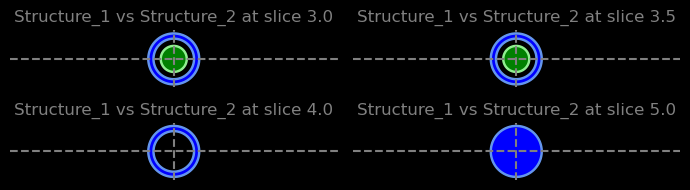

In [21]:
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(7, 2))
slice_idx = 3.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 3.5
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 4.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 5.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


In [22]:
slices = structures.slice_sequence.sequence
slices[~slices.Original]
slices

,ThisSlice,NextSlice,PreviousSlice,Original
ThisSlice,,,,
-15.25,-15.25,-15.0,NaN,False
-15.00,-15.00,-14.0,NaN,True
-14.00,-14.00,-13.0,-15.0,True
-13.00,-13.00,-12.0,-14.0,True
-12.00,-12.00,-11.0,-13.0,True
-11.00,-11.00,-10.0,-12.0,True
-10.00,-10.00,-9.0,-11.0,True
-9.00,-9.00,-8.0,-10.0,True
-8.00,-8.00,-7.0,-9.0,True


Region pair (1, 0):
  Slice -5.0 to -3.5: 1.50 cm
  Slice  5.0 to  3.5: 1.50 cm

Region pair (2, 0):
  Slice -5.5 to -3.5: 2.00 cm
  Slice -5.0 to -3.5: 1.50 cm
  Slice 5.0 to 3.5: 1.50 cm
  Slice 5.5 to 3.5: 2.00 cm

In [23]:
# Examine per-slice distances for detailed analysis
if distance_result.slice_distances:
    print("Per-Slice Distances:")
    for region_pair, slice_dists in distance_result.slice_distances.items():
        print(f"\nRegion pair {region_pair}:")
        for (slice_a, slice_b), dist in sorted(slice_dists.items()):
            print(f"  Slice {slice_a} to {slice_b}: {dist:.2f} cm")

In [24]:
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")
print(f"Closest Region Pair: {distance_result.closest_region_pair}")
print(f"Closest Slice: {distance_result.closest_slice}")

# Per-region distances (if multi-region structures)
if distance_result.per_region_minimum_distance:
    print("\nPer-Region Distances:")
    for region_pair, dist in distance_result.per_region_minimum_distance.items():
        print(f"  Region pair {region_pair}: {dist:.2f} cm")


Minimum Distance: nan cm
Closest Region Pair: None
Closest Slice: None


In [25]:
structure_a = structures.structures[1]
structure_b = structures.structures[2]
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)